# MVP profesional - Redes confiables para concesión de crédito

Este notebook ejecuta el MVP completo del taller sobre el dataset **Home Credit Default Risk**. Está diseñado para generar resultados, tablas y figuras utilizables en el repositorio y en la presentación.

El flujo cubre las cuatro tareas obligatorias:

1. **Arquitectura customizada:** capas financieras `FinancialRatiosLayer` y `TrainableGammaLayer`.
2. **Aprendizaje justo:** penalización FAIR con `FairnessPenalty`, basada en correlación entre predicción y género.
3. **AutoML:** búsqueda de arquitectura con Keras Tuner.
4. **Incertidumbre:** modelo secundario M2 que predice el error absoluto esperado del clasificador.

El MVP utiliza `application_train.csv`. Las tablas relacionales adicionales de Kaggle se reservan para la fase avanzada del proyecto.

## 0. Configuración global

Esta celda centraliza rutas, hiperparámetros principales y estilo visual. La ejecución profesional usa el dataset completo filtrado a `CODE_GENDER in {F, M}`.

Los parámetros elegidos son suficientemente serios para un MVP entregable: 15 trials de Keras Tuner, hasta 50 épocas y un barrido de 8 valores de `lambda_fair`.

In [1]:
from pathlib import Path
import sys
import os
import random
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ruta del proyecto. Si el notebook se abre desde la raíz, esta ruta coincide con Path.cwd().
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw"
RESULTS = PROJECT_ROOT / "results"
TABLES = RESULTS / "tables"
FIGURES = RESULTS / "figures"
MODELS = RESULTS / "models"

for directory in (TABLES, FIGURES, MODELS):
    directory.mkdir(parents=True, exist_ok=True)

# Aseguramos import local del paquete src.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Reproducibilidad razonable para la ejecución. TensorFlow también se inicializa
# dentro de los entrenadores del proyecto, pero fijamos semillas desde el notebook.
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

# Parámetros profesionales del MVP.
MAX_TRIALS = 15
EPOCHS = 50
BATCH_SIZE = 1024
LAMBDA_VALUES = (0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0)

# Estilo visual sobrio y legible para informe/presentación.
sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.frameon"] = True
warnings.filterwarnings("ignore", category=FutureWarning)

def save_figure(name: str) -> Path:
    """Guarda la figura actual en results/figures con resolución de informe."""
    path = FIGURES / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    return path

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Kernel:", sys.executable)
print("MAX_TRIALS:", MAX_TRIALS, "EPOCHS:", EPOCHS, "BATCH_SIZE:", BATCH_SIZE)


PROJECT_ROOT: C:\Users\dgall\OneDrive\Desktop\Master_MIAX_14\Modulo_4_IA_Avanzada\Taller TransferLearning AML
Kernel: c:\venvs\homecredit311\Scripts\python.exe
MAX_TRIALS: 15 EPOCHS: 50 BATCH_SIZE: 1024


## 1. Inventario de datos disponibles

Kaggle proporciona varias tablas. Para el MVP obligatorio trabajamos con `application_train.csv`, que contiene `TARGET`. El resto de CSVs se documentan aquí para mostrar disponibilidad y trazabilidad, pero no se mezclan en este notebook.

In [2]:
csv_files = sorted(DATA_RAW.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No hay CSVs en {DATA_RAW}.")

inventory = pd.DataFrame({
    "archivo": [path.name for path in csv_files],
    "tamaño_mb": [round(path.stat().st_size / 1024**2, 2) for path in csv_files],
})
display(inventory.sort_values("archivo"))

,archivo,tamaño_mb
5,HomeCredit_columns_description.csv,0.04
7,POS_CASH_balance.csv,374.51
0,application_test.csv,25.34
1,application_train.csv,158.44
2,bureau.csv,162.14
3,bureau_balance.csv,358.19
4,credit_card_balance.csv,404.91
6,installments_payments.csv,689.62
8,previous_application.csv,386.21
9,sample_submission.csv,0.51


## 2. Carga de datos principales

`TARGET=1` indica dificultad de pago. `CODE_GENDER` es la variable sensible. Las variables financieras y `EXT_SOURCE_*` son claves para predicción, capa custom e incertidumbre.

In [3]:
application_train_path = DATA_RAW / "application_train.csv"
if not application_train_path.exists():
    raise FileNotFoundError("Falta data/raw/application_train.csv")

raw = pd.read_csv(application_train_path)

print("Dimensiones application_train:", raw.shape)
display(raw.head())
display(raw[["TARGET", "CODE_GENDER", "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].head())

Dimensiones application_train: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


,TARGET,CODE_GENDER,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,1,M,202500.0,406597.5,24700.5,0.083037,0.262949,0.139376
1,0,F,270000.0,1293502.5,35698.5,0.311267,0.622246,NaN
2,0,M,67500.0,135000.0,6750.0,NaN,0.555912,0.729567
3,0,F,135000.0,312682.5,29686.5,NaN,0.650442,NaN
4,0,M,121500.0,513000.0,21865.5,NaN,0.322738,NaN


## 3. EDA: desbalance de clase y variable sensible

Antes de entrenar, verificamos dos hechos relevantes: el objetivo está desbalanceado y la variable sensible tiene distribución desigual. Esto justifica usar AUC/PR-AUC y auditar fairness.

,proporción
TARGET,
0,0.91927
1,0.08073


,P(TARGET=0),P(TARGET=1)
CODE_GENDER,,
F,0.930007,0.069993
M,0.898581,0.101419


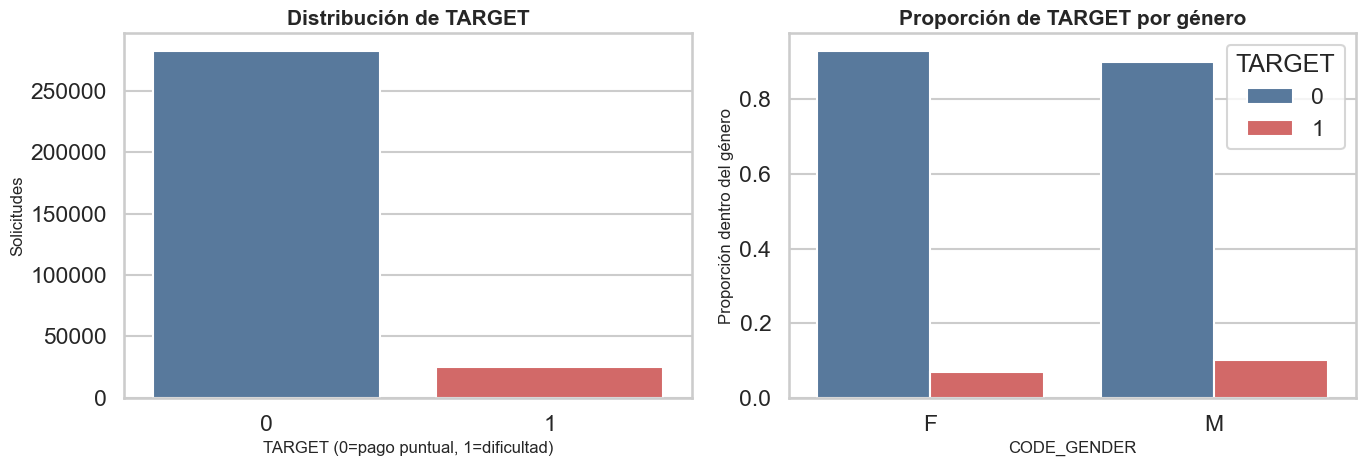

In [4]:
raw_fm = raw[raw["CODE_GENDER"].isin(["F", "M"])].copy()

target_summary = raw_fm["TARGET"].value_counts(normalize=True).rename("proporción").to_frame()
gender_target = pd.crosstab(raw_fm["CODE_GENDER"], raw_fm["TARGET"], normalize="index")
gender_target.columns = ["P(TARGET=0)", "P(TARGET=1)"]

display(target_summary)
display(gender_target)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=raw_fm, x="TARGET", ax=axes[0], palette=["#4C78A8", "#E45756"])
axes[0].set_title("Distribución de TARGET")
axes[0].set_xlabel("TARGET (0=pago puntual, 1=dificultad)")
axes[0].set_ylabel("Solicitudes")

gender_plot = raw_fm.groupby(["CODE_GENDER", "TARGET"]).size().reset_index(name="count")
gender_plot["prop"] = gender_plot.groupby("CODE_GENDER")["count"].transform(lambda s: s / s.sum())
sns.barplot(data=gender_plot, x="CODE_GENDER", y="prop", hue="TARGET", ax=axes[1], palette=["#4C78A8", "#E45756"])
axes[1].set_title("Proporción de TARGET por género")
axes[1].set_xlabel("CODE_GENDER")
axes[1].set_ylabel("Proporción dentro del género")

save_figure("eda_target_gender.png")
plt.show()

## 4. EDA: valores ausentes y calidad de fuentes externas

El enunciado destaca `EXT_SOURCE_1`, `EXT_SOURCE_2` y `EXT_SOURCE_3` porque contienen valores ausentes relevantes para analizar incertidumbre. Visualizamos missingness general y específico.

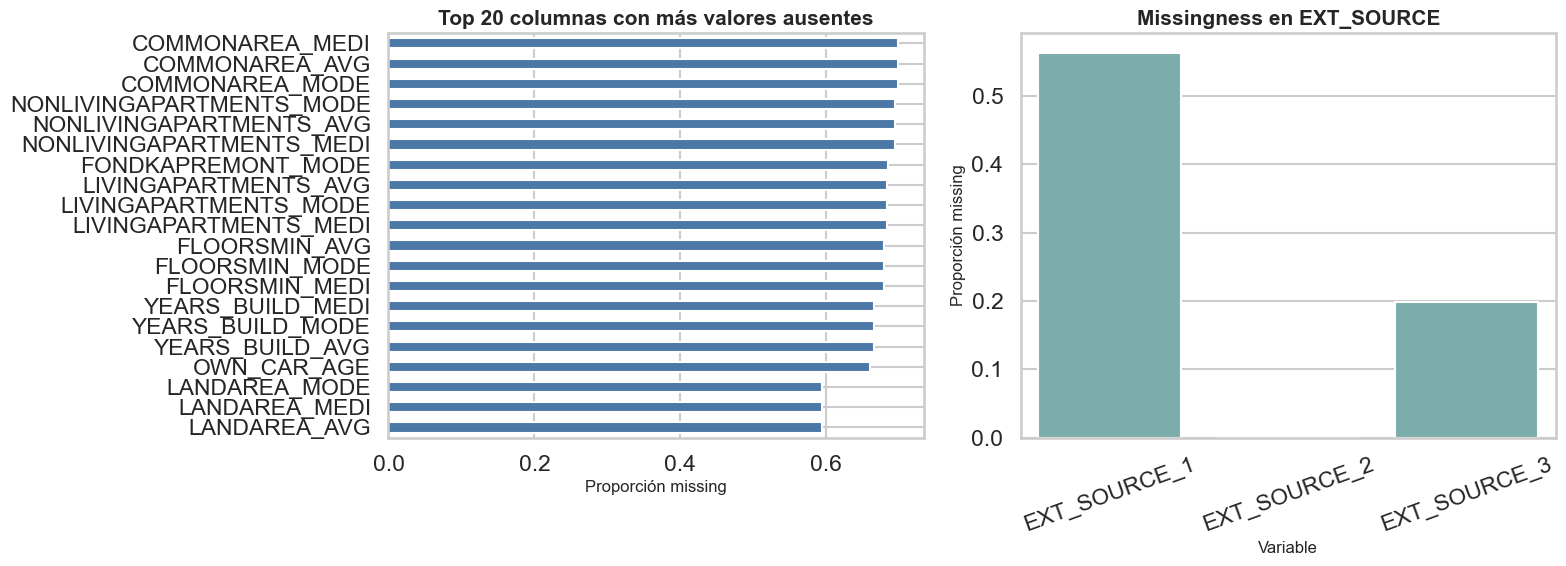

,proporción_missing
EXT_SOURCE_1,0.563812
EXT_SOURCE_2,0.002146
EXT_SOURCE_3,0.198256


In [5]:
missing = raw_fm.isna().mean().sort_values(ascending=False)
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
ext_missing = raw_fm[ext_cols].isna().mean().rename("proporción_missing")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

missing.head(20).sort_values().plot(kind="barh", ax=axes[0], color="#4C78A8")
axes[0].set_title("Top 20 columnas con más valores ausentes")
axes[0].set_xlabel("Proporción missing")

sns.barplot(x=ext_missing.index, y=ext_missing.values, ax=axes[1], color="#72B7B2")
axes[1].set_title("Missingness en EXT_SOURCE")
axes[1].set_xlabel("Variable")
axes[1].set_ylabel("Proporción missing")
axes[1].tick_params(axis="x", rotation=20)

save_figure("eda_missingness_ext_source.png")
plt.show()

display(ext_missing.to_frame())

## 5. EDA: variables financieras y fuentes externas

Las variables financieras tienen colas largas. Para visualizarlas usamos `log1p`, pero el pipeline de modelado mantiene los importes en escala monetaria para que la capa custom calcule ratios interpretables.

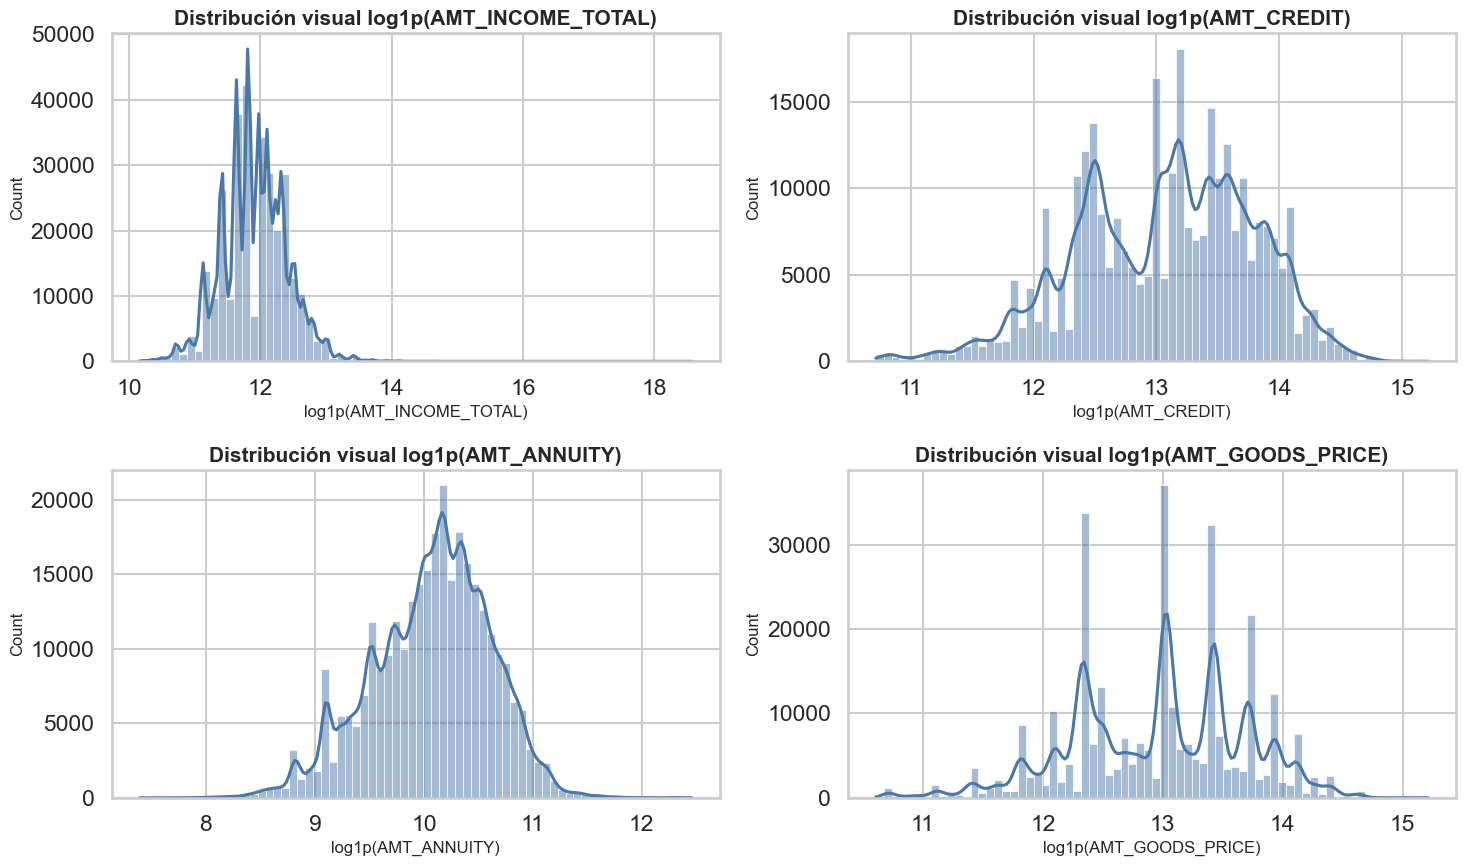

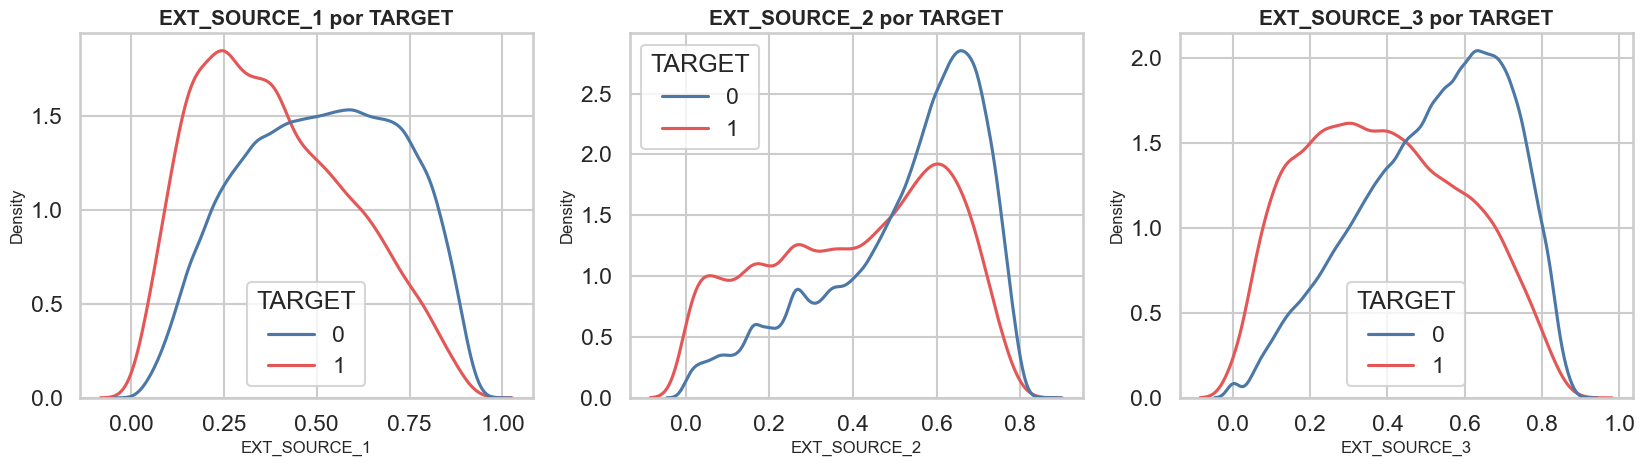

In [6]:
financial_cols = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for col, ax in zip(financial_cols, axes.ravel()):
    sns.histplot(np.log1p(raw_fm[col].dropna()), bins=70, kde=True, ax=ax, color="#4C78A8")
    ax.set_title(f"Distribución visual log1p({col})")
    ax.set_xlabel(f"log1p({col})")

save_figure("eda_financial_distributions.png")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for col, ax in zip(ext_cols, axes):
    sns.kdeplot(data=raw_fm, x=col, hue="TARGET", common_norm=False, ax=ax, palette=["#4C78A8", "#E45756"])
    ax.set_title(f"{col} por TARGET")

save_figure("eda_ext_source_by_target.png")
plt.show()

## 6. Pipeline MVP: contrato, transformaciones y split

Ejecutamos el código real de los Bloques 1-3. El split es 70/15/15 y está estratificado por la combinación `TARGET x SENSITIVE`, lo que preserva la composición de clase y género en train, validation y test.

In [7]:
from src.dani_credit.preprocessing import HomeCreditMVPPreprocessingPipeline
from src.dani_credit.splitting import HomeCreditTrainValTestSplitter, SplitConfig

pipeline = HomeCreditMVPPreprocessingPipeline()
raw_mvp = pipeline.load_raw(application_train_path)
deterministic = pipeline.apply_deterministic_transforms(raw_mvp)

splitter = HomeCreditTrainValTestSplitter(SplitConfig(test_size=0.15, validation_size=0.15, random_state=SEED))
split = splitter.split(deterministic)
processed = pipeline.fit_transform_splits(split.raw_splits)

print("raw_mvp:", raw_mvp.shape)
print("deterministic.features:", deterministic.features.shape)
print("X_train:", processed.X_train.shape)
print("X_val:", processed.X_val.shape)
print("X_test:", processed.X_test.shape)
display(split.report)

split.report.to_csv(TABLES / "split_report.csv", index=False)


raw_mvp: (307511, 18)
deterministic.features: (307507, 20)
X_train: (215254, 36)
X_val: (46126, 36)
X_test: (46127, 36)


,split,n,target_rate,sensitive_rate,target_0_sensitive_0,target_0_sensitive_1,target_1_sensitive_0,target_1_sensitive_1
0,train,215254,0.080733,0.341648,131794,66082,9919,7459
1,validation,46126,0.080714,0.341651,28242,14161,2125,1598
2,test,46127,0.080734,0.341644,28242,14161,2126,1598


## 7. Auditoría del preprocesamiento

Comprobamos que no hay NaNs tras imputación, que `CODE_GENDER` no entra como feature predictiva y que se conserva `EXT_NULL_COUNT` para el análisis de incertidumbre.

,valor
n_features,36
nan_X_train,0
nan_X_val,0
nan_X_test,0
CODE_GENDER_in_features,False
SENSITIVE_in_features,False
EXT_NULL_COUNT_in_features,True


,feature_name
0,AMT_INCOME_TOTAL
1,AMT_CREDIT
2,AMT_ANNUITY
3,AMT_GOODS_PRICE
4,AGE_YEARS
5,EMPLOYED_YEARS
6,EXT_SOURCE_1
7,EXT_SOURCE_2
8,EXT_SOURCE_3
9,EXT_NULL_COUNT


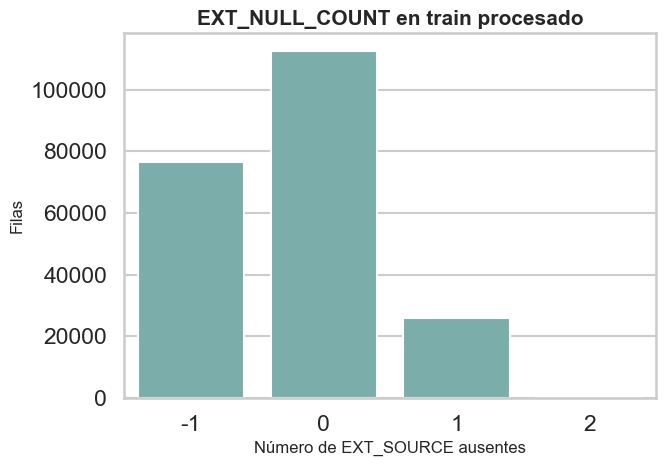

In [8]:
feature_names = tuple(processed.feature_names)

audit = {
    "n_features": len(feature_names),
    "nan_X_train": int(np.isnan(processed.X_train).sum()),
    "nan_X_val": int(np.isnan(processed.X_val).sum()),
    "nan_X_test": int(np.isnan(processed.X_test).sum()),
    "CODE_GENDER_in_features": "CODE_GENDER" in feature_names,
    "SENSITIVE_in_features": "SENSITIVE" in feature_names,
    "EXT_NULL_COUNT_in_features": "EXT_NULL_COUNT" in feature_names,
}
display(pd.Series(audit, name="valor").to_frame())
display(pd.Series(feature_names, name="feature_name").head(80).to_frame())

ext_null_idx = feature_names.index("EXT_NULL_COUNT")
plt.figure(figsize=(7, 5))
sns.countplot(x=processed.X_train[:, ext_null_idx].astype(int), color="#72B7B2")
plt.title("EXT_NULL_COUNT en train procesado")
plt.xlabel("Número de EXT_SOURCE ausentes")
plt.ylabel("Filas")
save_figure("preprocessing_ext_null_count.png")
plt.show()

## 8. Arquitectura customizada

La arquitectura custom cumple la Tarea 1:

```text
X -> FinancialRatiosLayer -> TrainableGammaLayer -> BatchNormalization -> Dense stack -> sigmoid
```

`FinancialRatiosLayer` añade ratios como `AMT_CREDIT / AMT_INCOME_TOTAL` y `AMT_ANNUITY / AMT_CREDIT`. `TrainableGammaLayer` aplica una saturación entrenable sobre los ratios para comprimir valores extremos sin perder monotonía.

In [9]:
from src.dani_credit.models import CustomMLPModelBuilder

index_resolver = CustomMLPModelBuilder().index_resolver
ratio_indices = index_resolver.resolve(feature_names)

ratio_info = pd.DataFrame({
    "variable": ["AMT_CREDIT", "AMT_ANNUITY", "AMT_INCOME_TOTAL", "AMT_GOODS_PRICE"],
    "indice_procesado": list(ratio_indices.as_tuple()),
})
display(ratio_info)

,variable,indice_procesado
0,AMT_CREDIT,1
1,AMT_ANNUITY,2
2,AMT_INCOME_TOTAL,0
3,AMT_GOODS_PRICE,3


## 9. AutoML con Keras Tuner

La Tarea 3 pide usar Keras Tuner. En esta ejecución se buscan 15 arquitecturas, optimizando `val_auc`, con presión FAIR moderada (`lambda_fair=0.5`). Después se fija la mejor arquitectura y se barre `lambda_fair`.

In [10]:
from src.dani_credit.tuning import FairKerasTunerRunner, FairLambdaSweepTrainer, TuningArtifactPaths, TuningConfig

tuning_config = TuningConfig(
    tuning_lambda_fair=0.5,
    lambda_values=LAMBDA_VALUES,
    max_trials=MAX_TRIALS,
    executions_per_trial=1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    early_stopping_patience=10,
    reduce_lr_patience=5,
    tuner_project_name="fair_credit_mvp_professional",
    overwrite_tuner=True,
)


La celda anterior define la configuración. La siguiente celda ejecuta la búsqueda y puede tardar. Si se interrumpe, se puede relanzar desde aquí.

In [11]:
# Configuración de rutas para artefactos de tuning.
artifacts = TuningArtifactPaths(project_root=PROJECT_ROOT)

tuner_runner = FairKerasTunerRunner(config=tuning_config, artifacts=artifacts)
search_result = tuner_runner.search(processed, verbose=1)

print("Mejor arquitectura encontrada:")
print("hidden_units:", search_result.best_config.hidden_units)
print("activation:", search_result.best_config.activation)
print("dropout:", search_result.best_config.dropout)
print("learning_rate:", search_result.best_config.learning_rate)

Trial 15 Complete [00h 01m 28s]
val_auc: 0.7374807000160217

Best val_auc So Far: 0.7443267107009888
Total elapsed time: 00h 15m 40s
Mejor arquitectura encontrada:
hidden_units: (256, 64, 128, 128)
activation: elu
dropout: 0.2
learning_rate: 0.000978041751919679


## 10. Barrido de `lambda_fair`

Con la arquitectura ganadora, entrenamos una familia de modelos. La comparación es controlada: solo cambia `lambda_fair`.

In [12]:
sweep_trainer = FairLambdaSweepTrainer(config=tuning_config, artifacts=artifacts)

sweep_result = sweep_trainer.run(
    data=processed,
    custom_config=search_result.best_config,
    ratio_indices=search_result.ratio_indices,
    class_weight=search_result.class_weight,
    save_models=True,
    verbose=1,
)

pareto = pd.read_csv(TABLES / "pareto_results.csv")
display(pareto)

Epoch 1/50
211/211 [==============================] - 4s 12ms/step - loss: 0.6136 - auc: 0.7259 - pr_auc: 0.1962 - binary_accuracy: 0.6647 - precision: 0.1498 - recall: 0.6744 - val_loss: 0.6569 - val_auc: 0.7312 - val_pr_auc: 0.2187 - val_binary_accuracy: 0.6241 - val_precision: 0.1407 - val_recall: 0.7161 - lr: 9.7804e-04 - val_abs_rho: 0.0625
Epoch 2/50
211/211 [==============================] - 2s 10ms/step - loss: 0.6036 - auc: 0.7374 - pr_auc: 0.2058 - binary_accuracy: 0.6743 - precision: 0.1550 - recall: 0.6813 - val_loss: 0.6200 - val_auc: 0.7344 - val_pr_auc: 0.2231 - val_binary_accuracy: 0.6593 - val_precision: 0.1489 - val_recall: 0.6831 - lr: 9.7804e-04 - val_abs_rho: 0.0937
Epoch 3/50
211/211 [==============================] - 2s 10ms/step - loss: 0.6022 - auc: 0.7392 - pr_auc: 0.2089 - binary_accuracy: 0.6744 - precision: 0.1550 - recall: 0.6817 - val_loss: 0.6201 - val_auc: 0.7379 - val_pr_auc: 0.2243 - val_binary_accuracy: 0.6652 - val_precision: 0.1516 - val_recall: 0.

,lambda_fair,val_auc,val_pr_auc,val_abs_rho,val_threshold,val_accuracy,val_precision,val_recall,val_f1,epochs_trained,model_path,history_path,selected_for_test
0,0.00,0.745874,0.236014,0.098362,0.481516,0.661839,0.152960,0.702928,0.251248,49,results/models/fair_lambda_0_0.keras,results/tables/history_fair_lambda_0_0.csv,True
1,0.05,0.745863,0.234721,0.089805,0.532670,0.732147,0.173870,0.618050,0.271392,31,results/models/fair_lambda_0_05.keras,results/tables/history_fair_lambda_0_05.csv,False
2,0.10,0.745624,0.236025,0.082708,0.519312,0.703703,0.163963,0.651625,0.262001,41,results/models/fair_lambda_0_1.keras,results/tables/history_fair_lambda_0_1.csv,False
3,0.25,0.745037,0.234187,0.060413,0.456856,0.629493,0.145945,0.739995,0.243805,41,results/models/fair_lambda_0_25.keras,results/tables/history_fair_lambda_0_25.csv,False
4,0.50,0.744002,0.234088,0.042580,0.516657,0.703833,0.164030,0.651625,0.262086,41,results/models/fair_lambda_0_5.keras,results/tables/history_fair_lambda_0_5.csv,False
5,1.00,0.742858,0.233438,0.025724,0.506618,0.688332,0.159540,0.670427,0.257745,41,results/models/fair_lambda_1_0.keras,results/tables/history_fair_lambda_1_0.csv,False
6,2.00,0.742150,0.232905,0.014460,0.508977,0.698283,0.162137,0.656997,0.260088,34,results/models/fair_lambda_2_0.keras,results/tables/history_fair_lambda_2_0.csv,False
7,5.00,0.740213,0.230716,0.009827,0.500768,0.681698,0.157296,0.675530,0.255175,30,results/models/fair_lambda_5_0.keras,results/tables/history_fair_lambda_5_0.csv,True


## 11. Curva de Pareto: rendimiento vs dependencia FAIR

Esta figura responde al requisito obligatorio: mostrar el trade-off entre rendimiento predictivo y dependencia con género.

- Eje X: `val_abs_rho = |corr(predicción, género)|`. Menor es mejor.
- Eje Y: `val_auc`. Mayor es mejor.
- Color: valor de `lambda_fair`.

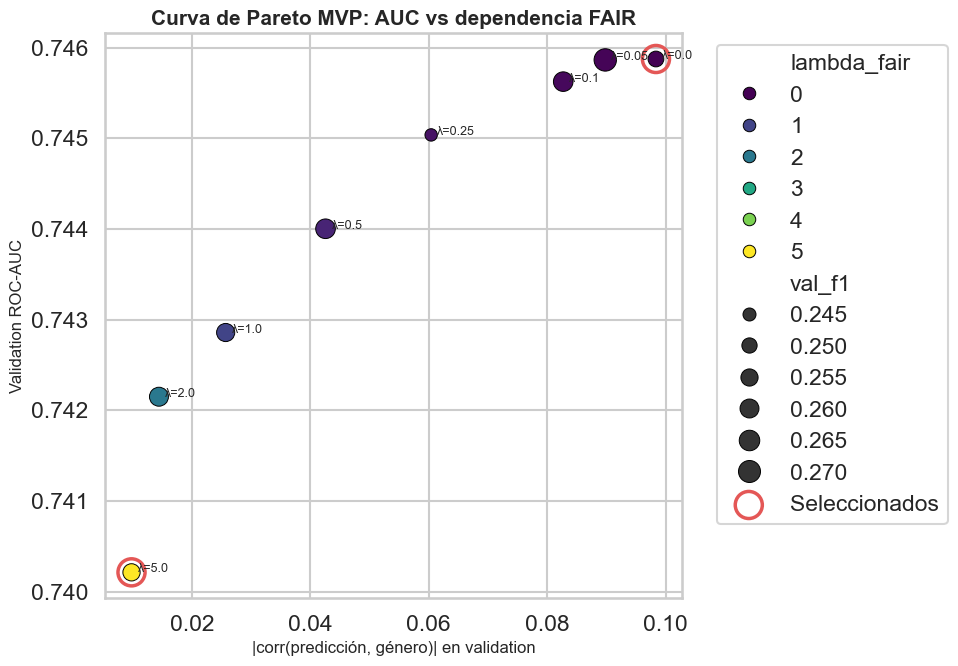

In [13]:
plt.figure(figsize=(10, 7))
scatter = sns.scatterplot(
    data=pareto,
    x="val_abs_rho",
    y="val_auc",
    hue="lambda_fair",
    size="val_f1",
    sizes=(80, 260),
    palette="viridis",
    edgecolor="black",
    linewidth=0.7,
)

for _, row in pareto.iterrows():
    label = f"λ={row['lambda_fair']}"
    plt.text(row["val_abs_rho"] + 0.001, row["val_auc"], label, fontsize=9)

selected = pareto[pareto["selected_for_test"] == True]
plt.scatter(selected["val_abs_rho"], selected["val_auc"], s=380, facecolors="none", edgecolors="#E45756", linewidths=2.5, label="Seleccionados")

plt.title("Curva de Pareto MVP: AUC vs dependencia FAIR")
plt.xlabel("|corr(predicción, género)| en validation")
plt.ylabel("Validation ROC-AUC")
plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
save_figure("pareto_auc_vs_fairness.png")
plt.show()

## 12. Selección de modelos finales

Para evaluación final se usan dos modelos de la misma familia dual-input:

- Base final: `lambda_fair=0.0`.
- FAIR final: modelo FAIR seleccionado en validation.

In [14]:
base_row = pareto[np.isclose(pareto["lambda_fair"], 0.0)].iloc[0]

fair_selected = pareto[(pareto["selected_for_test"] == True) & (~np.isclose(pareto["lambda_fair"], 0.0))]
if fair_selected.empty:
    fair_selected = pareto[~np.isclose(pareto["lambda_fair"], 0.0)].sort_values(["val_abs_rho", "val_auc"], ascending=[True, False]).head(1)
fair_row = fair_selected.iloc[0]

display(pd.DataFrame([base_row, fair_row], index=["Base final", "FAIR final"]))

,lambda_fair,val_auc,val_pr_auc,val_abs_rho,val_threshold,val_accuracy,val_precision,val_recall,val_f1,epochs_trained,model_path,history_path,selected_for_test
Base final,0.0,0.745874,0.236014,0.098362,0.481516,0.661839,0.152960,0.702928,0.251248,49,results/models/fair_lambda_0_0.keras,results/tables/history_fair_lambda_0_0.csv,True
FAIR final,5.0,0.740213,0.230716,0.009827,0.500768,0.681698,0.157296,0.675530,0.255175,30,results/models/fair_lambda_5_0.keras,results/tables/history_fair_lambda_5_0.csv,True


## 13. Curvas de convergencia

El enunciado exige curvas de loss para los entrenamientos finales. Mostramos loss train/validation y, en eje secundario, AUC y dependencia FAIR.

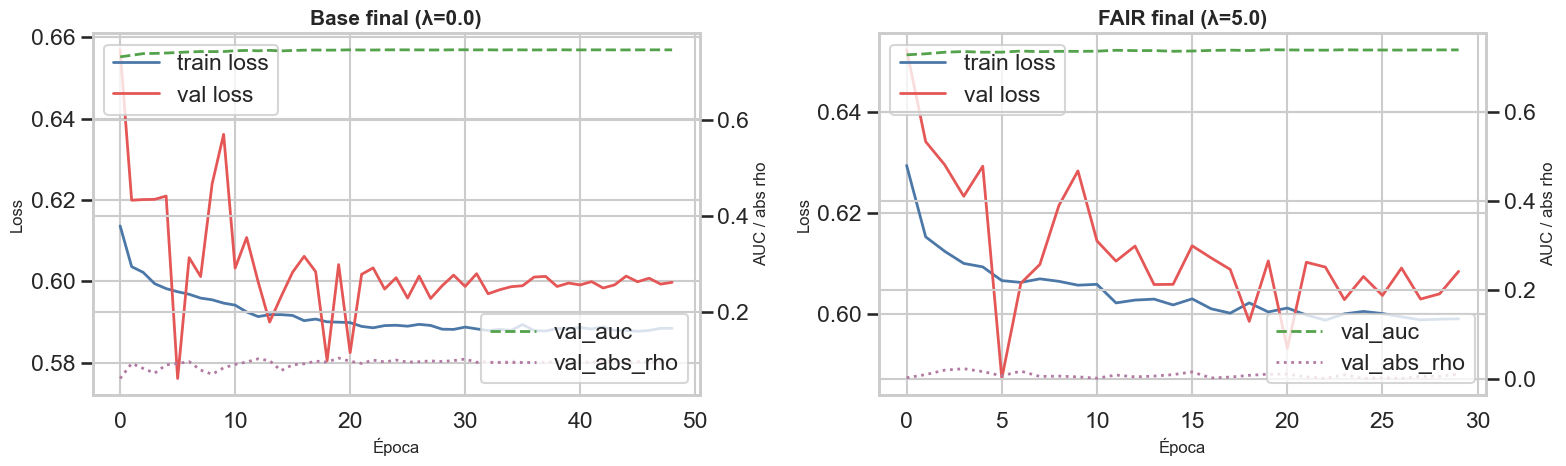

In [15]:
final_rows = pd.DataFrame([base_row, fair_row], index=["Base final", "FAIR final"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (name, row) in zip(axes, final_rows.iterrows()):
    history = pd.read_csv(PROJECT_ROOT / row["history_path"])
    ax.plot(history["loss"], label="train loss", color="#4C78A8", linewidth=2)
    ax.plot(history["val_loss"], label="val loss", color="#E45756", linewidth=2)
    ax.set_title(f"{name} (λ={row['lambda_fair']})")
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.legend(loc="upper left")

    ax2 = ax.twinx()
    if "val_auc" in history.columns:
        ax2.plot(history["val_auc"], label="val_auc", color="#54A24B", linestyle="--", linewidth=2)
    if "val_abs_rho" in history.columns:
        ax2.plot(history["val_abs_rho"], label="val_abs_rho", color="#B279A2", linestyle=":", linewidth=2)
    ax2.set_ylabel("AUC / abs rho")
    ax2.legend(loc="lower right")

save_figure("training_curves_base_vs_fair.png")
plt.show()

## 14. Evaluación final en test

El test no se usó para elegir arquitectura, lambda ni threshold. Ahora evaluamos base final y FAIR final en test usando el threshold elegido en validation para cada modelo.

In [16]:
from src.dani_credit.uncertainty import FairModelLoader
from src.dani_credit.tuning import DualInputFormatter
from src.dani_credit.metrics import ProbabilityMetricCalculator, BinaryClassificationMetricCalculator, FairnessMetricCalculator

formatter = DualInputFormatter()
loader = FairModelLoader()
prob_calc = ProbabilityMetricCalculator()
bin_calc = BinaryClassificationMetricCalculator()
fair_calc = FairnessMetricCalculator()

def predict_dual(model, X, s):
    """Predice probabilidades con un modelo dual-input features+sensitive."""
    return model.predict(formatter.format(X, s), batch_size=BATCH_SIZE, verbose=0).reshape(-1)

def evaluate_on_test(row, model_name):
    """Evalúa un modelo final en test con el threshold elegido en validation."""
    model = loader.load(PROJECT_ROOT / row["model_path"])
    proba = predict_dual(model, processed.X_test, processed.s_test)
    threshold = float(row["val_threshold"])
    prob = prob_calc.calculate(processed.y_test, proba, processed.s_test)
    binary = bin_calc.calculate(processed.y_test, proba, threshold)
    fairness = fair_calc.calculate(processed.y_test, proba, processed.s_test, threshold)
    return {
        "modelo": model_name,
        "lambda_fair": float(row["lambda_fair"]),
        "threshold": threshold,
        "auc": prob.roc_auc,
        "pr_auc": prob.pr_auc,
        "accuracy": binary.accuracy,
        "precision": binary.precision,
        "recall": binary.recall,
        "f1": binary.f1,
        "abs_rho": prob.abs_rho,
        "dpd": fairness.demographic_parity_difference,
        "eod": fairness.equalized_odds_difference,
        "y_proba": proba,
    }

base_eval = evaluate_on_test(base_row, "Base final")
fair_eval = evaluate_on_test(fair_row, "FAIR final")

test_results = pd.DataFrame([{k: v for k, v in item.items() if k != "y_proba"} for item in [base_eval, fair_eval]])
test_results.to_csv(TABLES / "test_results_base_vs_fair.csv", index=False)
display(test_results)

,modelo,lambda_fair,threshold,auc,pr_auc,accuracy,precision,recall,f1,abs_rho,dpd,eod
0,Base final,0.0,0.481516,0.743631,0.222811,0.657186,0.150990,0.702202,0.248539,0.097065,0.088874,0.080517
1,FAIR final,5.0,0.500768,0.738022,0.218571,0.674291,0.154138,0.676155,0.251047,0.008850,0.024762,0.015300


## 15. Comparativa visual en test

Resumimos el sacrificio de rendimiento y la mejora de fairness. Para métricas de error/fairness, menor es mejor; para AUC/F1/recall, mayor es mejor.

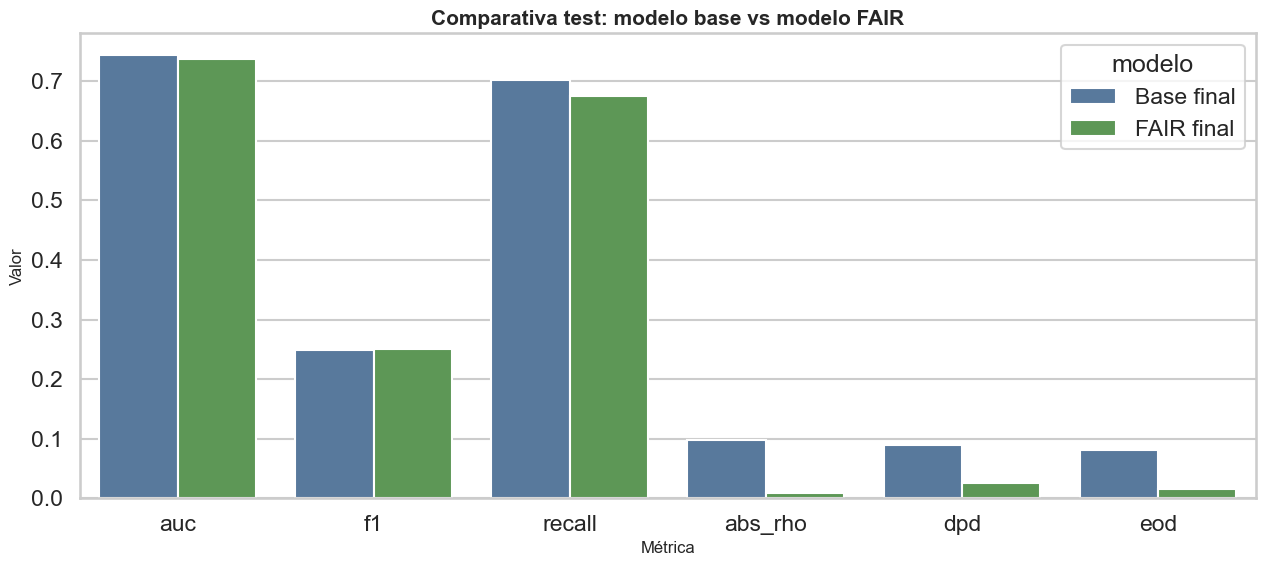

In [17]:
plot_metrics = ["auc", "f1", "recall", "abs_rho", "dpd", "eod"]
plot_df = test_results.melt(id_vars="modelo", value_vars=plot_metrics, var_name="métrica", value_name="valor")

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_df, x="métrica", y="valor", hue="modelo", palette=["#4C78A8", "#54A24B"])
plt.title("Comparativa test: modelo base vs modelo FAIR")
plt.xlabel("Métrica")
plt.ylabel("Valor")
save_figure("test_metrics_base_vs_fair.png")
plt.show()

## 16. Incertidumbre MVP

Entrenamos M2 para predecir el error absoluto esperado del modelo FAIR final. Este bloque responde a la Tarea 4: devolver predicción e incertidumbre en test.

In [18]:
from src.dani_credit.uncertainty import UncertaintyMVPTrainer, UncertaintyModelConfig, UncertaintyArtifactPaths

fair_model = loader.load(PROJECT_ROOT / fair_row["model_path"])

uncertainty_trainer = UncertaintyMVPTrainer(
    config=UncertaintyModelConfig(
        hidden_units=(32,),
        dropout=0.3,
        batch_size=BATCH_SIZE,
        epochs=50,
        early_stopping_patience=10,
    ),
    artifacts=UncertaintyArtifactPaths(project_root=PROJECT_ROOT),
)

uncertainty_result = uncertainty_trainer.run(
    m1_model=fair_model,
    data=processed,
    selected_threshold=float(fair_row["val_threshold"]),
    save_artifacts=True,
    save_model=True,
    verbose=1,
)

unc = pd.read_csv(TABLES / "uncertainty_test.csv")
unc_summary = pd.read_csv(TABLES / "uncertainty_summary_by_target.csv")
display(unc.head())
display(unc_summary)

Epoch 1/50
37/37 [==============================] - 0s 3ms/step - loss: 121.6553 - val_loss: 0.4091
Epoch 2/50
37/37 [==============================] - 0s 2ms/step - loss: 4.8335 - val_loss: 0.4091
Epoch 3/50
37/37 [==============================] - 0s 1ms/step - loss: 2.5463 - val_loss: 0.4091
Epoch 4/50
37/37 [==============================] - 0s 2ms/step - loss: 0.6628 - val_loss: 0.4091
Epoch 5/50
37/37 [==============================] - 0s 2ms/step - loss: 0.8562 - val_loss: 0.4091
Epoch 6/50
37/37 [==============================] - 0s 2ms/step - loss: 0.4089 - val_loss: 0.4091
Epoch 7/50
37/37 [==============================] - 0s 2ms/step - loss: 0.4089 - val_loss: 0.4091
Epoch 8/50
37/37 [==============================] - 0s 2ms/step - loss: 0.4089 - val_loss: 0.4091
Epoch 9/50
37/37 [==============================] - 0s 1ms/step - loss: 0.4585 - val_loss: 0.4091
Epoch 10/50
37/37 [==============================] - 0s 1ms/step - loss: 0.4089 - val_loss: 0.4091
Epoch 11/50
37/37

,SK_ID_CURR,y_true,y_proba,y_pred_label,sensitive,threshold,uncertainty,EXT_NULL_COUNT
0,115177,0,0.396257,0,0,0.500768,0.0,-1.0
1,353727,0,0.219442,0,0,0.500768,0.0,-1.0
2,430036,0,0.759136,1,1,0.500768,0.0,0.0
3,300897,0,0.815262,1,0,0.500768,0.0,0.0
4,135159,0,0.311581,0,1,0.500768,0.0,-1.0


,y_true,count,uncertainty_mean,uncertainty_median,uncertainty_q1,uncertainty_q3,uncertainty_iqr
0,0,42403,0.0,0.0,0.0,0.0,0.0
1,1,3724,0.0,0.0,0.0,0.0,0.0


## 17. Distribución de incertidumbre por clasificación

El enunciado pide comparar la incertidumbre entre perfiles clasificados como buen pagador y mal pagador. Usamos `y_pred_label`: 0 representa buen pagador predicho y 1 representa dificultad predicha.

C:\Users\dgall\AppData\Local\Temp\ipykernel_43336\2022586800.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=unc, x="uncertainty", hue="grupo_predicho", common_norm=False, fill=True, alpha=0.25)


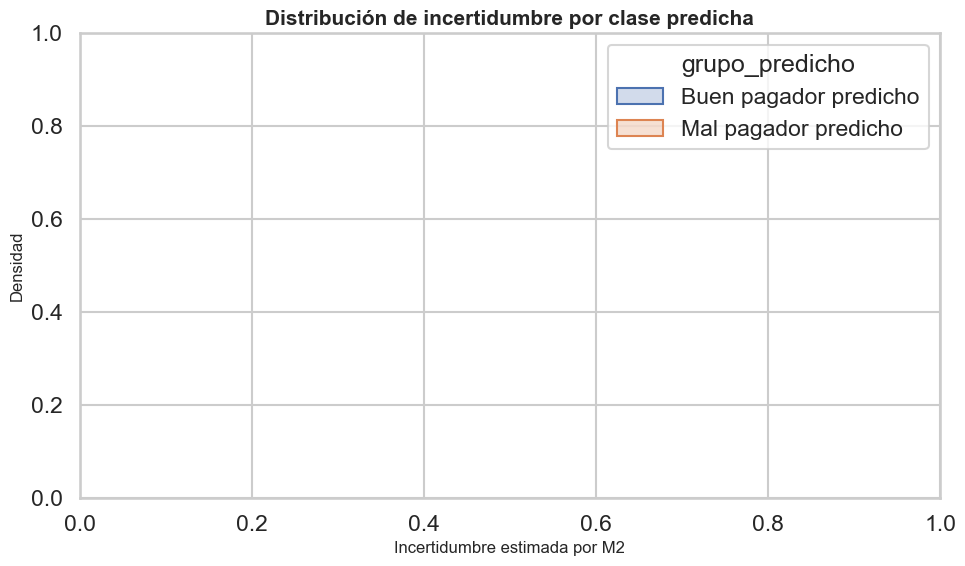

C:\Users\dgall\AppData\Local\Temp\ipykernel_43336\2022586800.py:13: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=unc, x="uncertainty", hue="grupo_real", common_norm=False, fill=True, alpha=0.25)


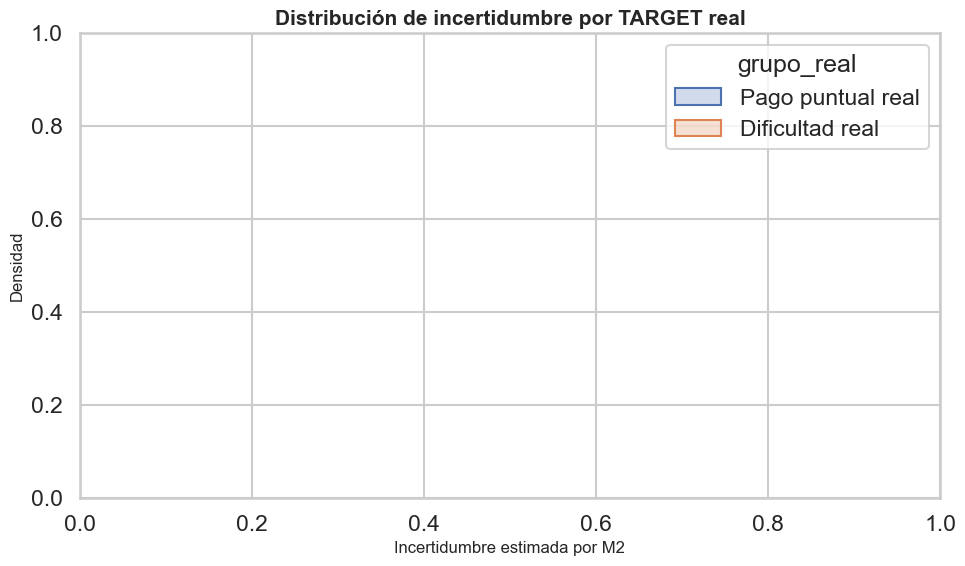

In [19]:
unc["grupo_predicho"] = unc["y_pred_label"].map({0: "Buen pagador predicho", 1: "Mal pagador predicho"})
unc["grupo_real"] = unc["y_true"].map({0: "Pago puntual real", 1: "Dificultad real"})

plt.figure(figsize=(10, 6))
sns.kdeplot(data=unc, x="uncertainty", hue="grupo_predicho", common_norm=False, fill=True, alpha=0.25)
plt.title("Distribución de incertidumbre por clase predicha")
plt.xlabel("Incertidumbre estimada por M2")
plt.ylabel("Densidad")
save_figure("uncertainty_distribution_by_predicted_class.png")
plt.show()

plt.figure(figsize=(10, 6))
sns.kdeplot(data=unc, x="uncertainty", hue="grupo_real", common_norm=False, fill=True, alpha=0.25)
plt.title("Distribución de incertidumbre por TARGET real")
plt.xlabel("Incertidumbre estimada por M2")
plt.ylabel("Densidad")
save_figure("uncertainty_distribution_by_target.png")
plt.show()

## 18. EXT_SOURCE e incertidumbre

Analizamos si el modelo muestra mayor incertidumbre cuando la calidad de las fuentes externas es peor, aproximada por `EXT_NULL_COUNT`.

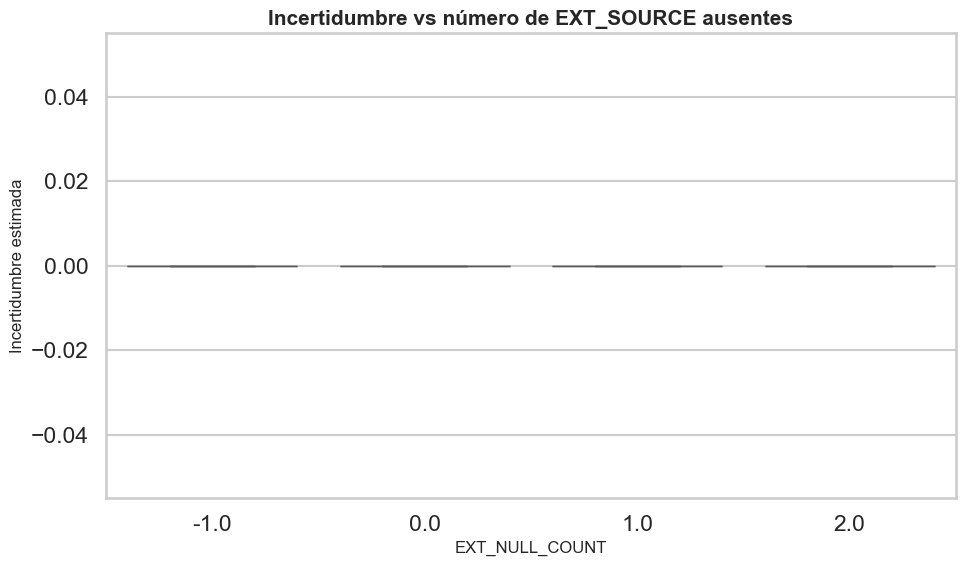

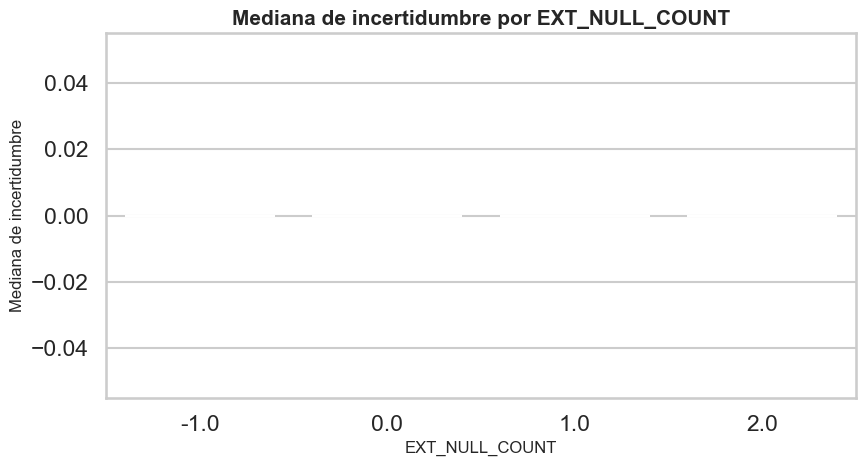

,EXT_NULL_COUNT,count,mean,median
0,-1.0,16448,0.0,0.0
1,0.0,24140,0.0,0.0
2,1.0,5511,0.0,0.0
3,2.0,28,0.0,0.0


In [20]:
ext_unc_summary = (
    unc.groupby("EXT_NULL_COUNT")["uncertainty"]
    .agg(count="count", mean="mean", median="median")
    .reset_index()
)
ext_unc_summary.to_csv(TABLES / "uncertainty_by_ext_null_count.csv", index=False)

plt.figure(figsize=(10, 6))
sns.boxplot(data=unc, x="EXT_NULL_COUNT", y="uncertainty", color="#72B7B2")
plt.title("Incertidumbre vs número de EXT_SOURCE ausentes")
plt.xlabel("EXT_NULL_COUNT")
plt.ylabel("Incertidumbre estimada")
save_figure("ext_null_count_vs_uncertainty_boxplot.png")
plt.show()

plt.figure(figsize=(9, 5))
sns.barplot(data=ext_unc_summary, x="EXT_NULL_COUNT", y="median", color="#54A24B")
plt.title("Mediana de incertidumbre por EXT_NULL_COUNT")
plt.xlabel("EXT_NULL_COUNT")
plt.ylabel("Mediana de incertidumbre")
save_figure("ext_null_count_vs_uncertainty_median.png")
plt.show()

display(ext_unc_summary)

## 19. Resumen ejecutivo del MVP

Esta celda resume los resultados principales que se pueden trasladar al PDF y a la defensa oral.

In [21]:
base_auc = float(test_results.loc[test_results["modelo"] == "Base final", "auc"].iloc[0])
fair_auc = float(test_results.loc[test_results["modelo"] == "FAIR final", "auc"].iloc[0])
base_rho = float(test_results.loc[test_results["modelo"] == "Base final", "abs_rho"].iloc[0])
fair_rho = float(test_results.loc[test_results["modelo"] == "FAIR final", "abs_rho"].iloc[0])

summary_lines = [
    f"Filas usadas: train={processed.X_train.shape[0]}, validation={processed.X_val.shape[0]}, test={processed.X_test.shape[0]}",
    f"Número de features procesadas: {len(feature_names)}",
    f"Mejor arquitectura: hidden_units={search_result.best_config.hidden_units}, activation={search_result.best_config.activation}, dropout={search_result.best_config.dropout:.2f}",
    f"AUC test base: {base_auc:.4f}",
    f"AUC test FAIR: {fair_auc:.4f}",
    f"|rho| test base: {base_rho:.4f}",
    f"|rho| test FAIR: {fair_rho:.4f}",
    f"Diferencia AUC FAIR-base: {fair_auc - base_auc:.4f}",
    f"Reducción |rho| base-FAIR: {base_rho - fair_rho:.4f}",
]

for line in summary_lines:
    print("-", line)

pd.Series(summary_lines, name="resumen_mvp").to_csv(TABLES / "mvp_executive_summary.csv", index=False)

display(test_results)
display(pareto)

- Filas usadas: train=215254, validation=46126, test=46127
- Número de features procesadas: 36
- Mejor arquitectura: hidden_units=(256, 64, 128, 128), activation=elu, dropout=0.20
- AUC test base: 0.7436
- AUC test FAIR: 0.7380
- |rho| test base: 0.0971
- |rho| test FAIR: 0.0088
- Diferencia AUC FAIR-base: -0.0056
- Reducción |rho| base-FAIR: 0.0882


,modelo,lambda_fair,threshold,auc,pr_auc,accuracy,precision,recall,f1,abs_rho,dpd,eod
0,Base final,0.0,0.481516,0.743631,0.222811,0.657186,0.150990,0.702202,0.248539,0.097065,0.088874,0.080517
1,FAIR final,5.0,0.500768,0.738022,0.218571,0.674291,0.154138,0.676155,0.251047,0.008850,0.024762,0.015300


,lambda_fair,val_auc,val_pr_auc,val_abs_rho,val_threshold,val_accuracy,val_precision,val_recall,val_f1,epochs_trained,model_path,history_path,selected_for_test
0,0.00,0.745874,0.236014,0.098362,0.481516,0.661839,0.152960,0.702928,0.251248,49,results/models/fair_lambda_0_0.keras,results/tables/history_fair_lambda_0_0.csv,True
1,0.05,0.745863,0.234721,0.089805,0.532670,0.732147,0.173870,0.618050,0.271392,31,results/models/fair_lambda_0_05.keras,results/tables/history_fair_lambda_0_05.csv,False
2,0.10,0.745624,0.236025,0.082708,0.519312,0.703703,0.163963,0.651625,0.262001,41,results/models/fair_lambda_0_1.keras,results/tables/history_fair_lambda_0_1.csv,False
3,0.25,0.745037,0.234187,0.060413,0.456856,0.629493,0.145945,0.739995,0.243805,41,results/models/fair_lambda_0_25.keras,results/tables/history_fair_lambda_0_25.csv,False
4,0.50,0.744002,0.234088,0.042580,0.516657,0.703833,0.164030,0.651625,0.262086,41,results/models/fair_lambda_0_5.keras,results/tables/history_fair_lambda_0_5.csv,False
5,1.00,0.742858,0.233438,0.025724,0.506618,0.688332,0.159540,0.670427,0.257745,41,results/models/fair_lambda_1_0.keras,results/tables/history_fair_lambda_1_0.csv,False
6,2.00,0.742150,0.232905,0.014460,0.508977,0.698283,0.162137,0.656997,0.260088,34,results/models/fair_lambda_2_0.keras,results/tables/history_fair_lambda_2_0.csv,False
7,5.00,0.740213,0.230716,0.009827,0.500768,0.681698,0.157296,0.675530,0.255175,30,results/models/fair_lambda_5_0.keras,results/tables/history_fair_lambda_5_0.csv,True
